# Grouping


In [1]:
import numpy as np
import pandas as pd

# Load Palmer penguins data
URL = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv'
penguins = pd.read_csv(URL)

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


Summary statistics

It is easy to get summary statistics for each column in a pandas.DataFrame by using methods such as:

    sum(): sum values in each column,
    count(): count non-NA values in each column,
    size(): count the number of values in a column (including NA values),
    min() and max(): get the minimum and maximum value in each column,
    mean() and median(): get the mean and median value in each column,
    std() and var(): get the standard deviation and variance in each column.


In [2]:
# Get the number of non-NA values in each column 
penguins.count()

species              344
island               344
bill_length_mm       342
bill_depth_mm        342
flipper_length_mm    342
body_mass_g          342
sex                  333
year                 344
dtype: int64

In [3]:
# Get minimum value in each column with numerical values
penguins.select_dtypes('number').min()

bill_length_mm         32.1
bill_depth_mm          13.1
flipper_length_mm     172.0
body_mass_g          2700.0
year                 2007.0
dtype: float64

## Grouping 
This is known as the Split-Apply-Combine strategy. This strategy follows the three steps we explained above:

    Split: Split the data into logical groups (e.g. species, sex, island, etc.)

    Apply: Calculate some summary statistic on each group (e.g. average flipper length by species, number of individuals per island, body mass by sex, etc.)

    Combine: Combine the statistic calculated on each group back together.


The general syntax for groupby() is

df.groupby(columns_to_group_by).summary_method()

Most often, columns_to_group_by is a single column name (a string) or a list of column names. The unique values of the column (or columns) will be used as the groups of the data frame.

In [5]:
# Without groupby() you are directly applying the mean of all values in the column
penguins['flipper_length_mm'].mean()

200.91520467836258

In [6]:
# Average flipper length per species
penguins.groupby('species')['flipper_length_mm'].mean()

species
Adelie       189.953642
Chinstrap    195.823529
Gentoo       217.186992
Name: flipper_length_mm, dtype: float64

In [7]:
# Average flipper length per species
avg_flipper = (penguins.groupby('species')
                        ['flipper_length_mm']
                        .mean()
                        .rename('mean_flipper_length')
                        .sort_values(ascending=False)
                        )
avg_flipper

species
Gentoo       217.186992
Chinstrap    195.823529
Adelie       189.953642
Name: mean_flipper_length, dtype: float64

In [11]:
# Average flipper length per species and island
avg_flipper_species_island = (penguins.groupby(['species','island'])
                                ['flipper_length_mm']
                                .mean()
                                .rename('mean_flipper_length')
                                .sort_values(ascending=False)
                                )

In [10]:
# Average flipper length per species and island
avg_flipper_species_island = (penguins.groupby(['species','island'])
                                ['flipper_length_mm']
                                .mean()
                                .rename('mean_flipper_length')
                                .sort_values(ascending=False)
                                )
avg_flipper_species_island

species    island   
Gentoo     Biscoe       217.186992
Chinstrap  Dream        195.823529
Adelie     Torgersen    191.196078
           Dream        189.732143
           Biscoe       188.795455
Name: mean_flipper_length, dtype: float64

## Grouping & NA values
size: returns the number of observations in a pandas.Series
count(): returns the number of non-NA observations in the series

In [15]:
# Number of NA observations
penguins['sex'].size - penguins['sex'].count()

11

In [18]:
# By default group() leaves out the rows where the grouping columns has NA values.
penguins.groupby('sex').size()

sex
female    165
male      168
dtype: int64

In [19]:
# To keep the NA values as their own group, we use the dropna=False parameter:
penguins.groupby('sex', dropna=False).size()

sex
female    165
male      168
NaN        11
dtype: int64

# Check-in

In [20]:
# 1. 

In [26]:
penguins.groupby(['island','year']).count().info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 9 entries, ('Biscoe', 2007) to ('Torgersen', 2009)
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   species            9 non-null      int64
 1   bill_length_mm     9 non-null      int64
 2   bill_depth_mm      9 non-null      int64
 3   flipper_length_mm  9 non-null      int64
 4   body_mass_g        9 non-null      int64
 5   sex                9 non-null      int64
dtypes: int64(6)
memory usage: 606.0+ bytes


In [27]:
penguins.groupby(['island','year']).size().info()

<class 'pandas.core.series.Series'>
MultiIndex: 9 entries, ('Biscoe', 2007) to ('Torgersen', 2009)
Series name: None
Non-Null Count  Dtype
--------------  -----
9 non-null      int64
dtypes: int64(1)
memory usage: 246.0+ bytes


In [ ]:
#2

Discuss the differences between each output. What method would give you the number of penguins surveyed on each island and year combination?

.count() returns a pandas data frame and .size() returns a pandas series, you can use .info() at the end to identify the class of each object.

<Axes: title={'center': 'Penguins surveyed at the Palmer Archipelago'}, xlabel='Number of penguins', ylabel='Island, Year'>

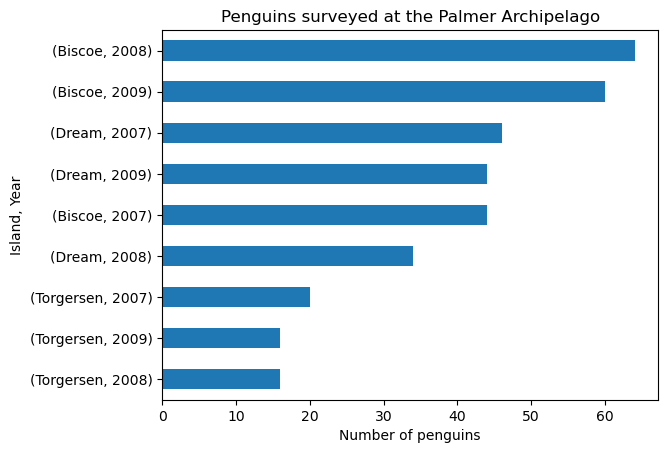

In [28]:
# plot the surveyed population per year and island. We could then use method chaining to do this:
(penguins.groupby(['island','year'])
         .size()
         .sort_values()
         .plot(kind='barh',
                title='Penguins surveyed at the Palmer Archipelago',
                xlabel='Number of penguins',
                ylabel='Island, Year')
         )

## Check-in 

In [29]:
#1. Use the max() method to calculate the maximum value of a penguin’s body mass by year and species.

In [53]:
max_species_bodymass =(penguins.groupby(['species','year'])['body_mass_g'].max().sort_values())
max_species_bodymass

species    year
Chinstrap  2007    4400.0
           2009    4450.0
Adelie     2007    4675.0
           2008    4700.0
           2009    4775.0
Chinstrap  2008    4800.0
Gentoo     2008    6000.0
           2009    6000.0
           2007    6300.0
Name: body_mass_g, dtype: float64

In [30]:
#2. Use (1) to display the highest body masses per year and species as a bar plot in descending order.

<Axes: title={'center': 'Penguins surveyed at the Palmer Archipelago'}, xlabel='body_mass_g', ylabel='Island, Year'>

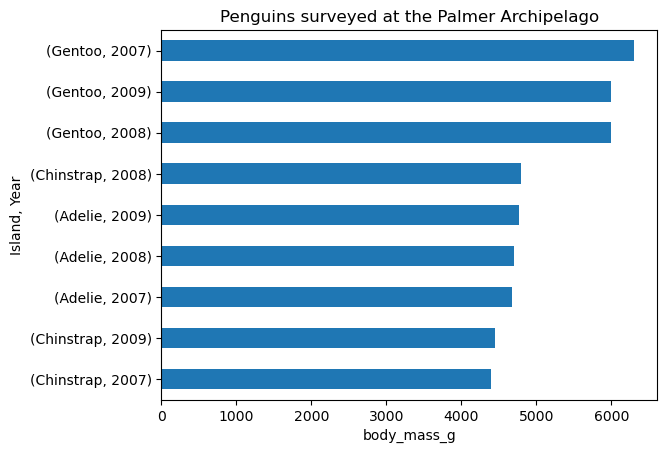

In [54]:
max_species_bodymass.plot(kind='barh',
                title='Penguins surveyed at the Palmer Archipelago',
                xlabel='body_mass_g',
                ylabel='Island, Year'
    
)